
# DISC5105 Week 3 Tutorial
## Machine Learning: Ergonomic assessment using ML
**In-class activity:** An Ergonomic Assessment Tool With a Smartphone in Pocket

**Assignment A2:** Build ML models using provided dataset, compare KNN/SVM/random forest models, and give improvement proposal.

**Data source:** A 20-min video with labelled sensor data of a scaffolder moving steel bars, including desired amount of standing, walking, bending, and squatting motions.

### Objective
We will build three different machine learning models to predict construction workers' posture using a prepared dataset consisting of sensors' data collected using a smartphone and labels of concerned postures (standing, walking, bending, and squatting). An evaluation and comparison will be done after training. Four stages wil be included:

1. Data preparation.
    * Load and check out data info
2. Feature selection
    * Select important features by ranking
3. Model Training.
    * Train KNN model.
    * Train SVM model.
    * Train RandomForest model.
4. Model Evaluation
    * Assess Accuracy, Recall Rate, Precision, and F1-score for each model.
    * A comparison of three models.


---
###   Steps
1. Setup environment
2. Load preprocessed data
3. Feature selection
4. Model training
5. Evaluation & Comparison


## Learning outcomes

By the end of this in-class assignment, you should be able to:

1. Inspect an annotated smartphone-sensor dataset and identify the posture labels.
2. Prepare features and labels for a supervised multi-class classification task.
3. Apply feature selection and explain why selected sensor features may help distinguish postures.
4. Build KNN, SVM, and Random Forest classification models.
5. Use a validation set to support model selection and reserve a test set for final evaluation.
6. Evaluate and compare models using Accuracy, macro Precision, macro Recall, macro F1-score, and confusion matrices.


> **Important:** A2 is an **in-class assignment**. Complete the notebook, ensure all required outputs are visible, export it as a PDF, and submit before leaving.


## 60-minute flow

| Time | Activity | Student output | Marks |
|---|---|---|---:|
| 0–5 min | Objectives, context, and assessment briefing | Identify the four posture classes and state the multi-class classification objective | 5 |
| 5–13 min | Inspect data and labels | Dataset shape, variable/data-type check, label identification, and class-distribution table or plot | 15 |
| 13–20 min | Prepare modelling data | Feature matrix and target definition; stratified 60/20/20 train-validation-test split; short note on avoiding data leakage | 15 |
| 20–30 min | Build baseline model: KNN | Standardized KNN pipeline, validation metrics, validation confusion matrix, and one brief interpretation | 15 |
| 30–40 min | Complete feature-selection task | Top-20 feature list and explanations for at least three selected features | 20 |
| 40–52 min | Train SVM and Random Forest | Completed SVM and RF models, validation results, and clearly stated key settings | 15 |
| 52–58 min | Final test evaluation and comparison | Test-set comparison table, comparison plot, best-model selection justified using macro F1-score | 15 |
| 58–60 min | Submit | Exported PDF with visible code, outputs, figures, and written answers | - |
|  | **Total** |  | **100** |

Step 1: Setup environment

In [1]:
import math
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from google.colab import files
import io

In [2]:
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['font.size'] = 14
plt.rcParams['font.serif'] = 'Times New Roman'
warnings.filterwarnings("ignore")


## Step 2: Inspect the dataset — 15 points
Upload the sensor dataset file downloaded from Canvas assignment 2.
The provided dataset contains smartphone sensor data collected while a construction worker performed four postures:

| Original label | Posture |
|---:|---|
| 1 | Standing |
| 2 | Walking |
| 5 | Bending |
| 8 | Squatting |

### Your task

1. Display the dataset shape, column names, and data types.
2. Identify the label column and the sensor-feature columns.
3. Produce a class-distribution table or bar chart for `Label_2`.
4. In 1–2 sentences, comment on whether the four posture classes appear balanced.

The magnetometer variables are not used because steel reinforcement in the work environment may strongly disturb magnetic signals. Identifier, timestamp, and other non-sensor columns should not be used as model inputs.

In [ ]:
print("Please upload your dataset.")
uploaded = files.upload()
if not uploaded:
    raise RuntimeError("No file uploaded.")
fname = next(iter(uploaded.keys()))
print(f"Loaded: {fname}")

# Try reading with default, fallback to tab-separated
try:
    df = pd.read_csv(io.BytesIO(uploaded[fname]))
except Exception:
    df = pd.read_csv(io.BytesIO(uploaded[fname]), sep='\t')

Please upload your dataset.


In [ ]:
smoothed_data = df
smoothed_data

,Unnamed: 0,Accelerometer.xlsx_x,Accelerometer.xlsx_y,Accelerometer.xlsx_z,Gravity_x,Gravity_y,Gravity_z,Gyroscope_x,Gyroscope_y,Gyroscope_z,seconds_elapsed,time,Real Time,Label_2
0,2,0.557599,-2.800918,0.340137,-1.493535,9.667788,-0.689534,-0.100186,0.291875,-0.294971,146.087010,1632193891370010112,2021/09/21 11:11:31.184,2.0
1,3,0.294163,-3.112110,0.545655,-1.499870,9.667765,-0.676663,-0.100186,0.193526,-0.220446,146.106844,1632193891389839872,2021/09/21 11:11:31.203,2.0
2,4,0.074176,-3.305158,0.721679,-1.506142,9.667743,-0.663833,-0.113625,0.159317,-0.134925,146.126679,1632193891409679872,2021/09/21 11:11:31.223,2.0
3,5,-0.095487,-3.353319,0.859823,-1.512335,9.667719,-0.651075,-0.111181,0.056081,-0.040241,146.146513,1632193891429509888,2021/09/21 11:11:31.243,2.0
4,6,-0.216963,-3.237498,0.960322,-1.518434,9.667695,-0.638418,-0.100186,-0.088694,0.016570,146.166347,1632193891449349888,2021/09/21 11:11:31.263,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46494,59982,-0.015903,0.054486,0.026917,-2.241180,3.408407,-8.917875,0.029929,0.020040,-0.090332,1341.458708,1632195086741710080,2021/09/21 11:31:26.555,8.0
46495,59983,-0.036015,0.047404,0.030700,-2.241347,3.407958,-8.918006,0.029929,0.020040,-0.090332,1341.478543,1632195086761540096,2021/09/21 11:31:26.575,8.0
46496,59984,-0.054879,0.042772,0.029788,-2.241499,3.407556,-8.918123,0.029929,0.014542,-0.079336,1341.498378,1632195086781380096,2021/09/21 11:31:26.595,8.0
46497,59985,-0.067747,0.040911,0.025526,-2.241636,3.407199,-8.918226,0.023820,0.011488,-0.058567,1341.518213,1632195086801210112,2021/09/21 11:31:26.615,8.0




1.   Check data frame info.
2.   In the datasert, label_2 (posture) is defined as：
  1.standing
  2.walking
  5.bending
  8.squatting
3.   After checking data, magnetometer is found hugely disturbed by massive amount of steel bars in environment. So Magnetometer_x, Magnetometer_y, Magnetometer_z need to be dropped. Subject names and positions are also irrelevent for further training. Drop them as well.









In [ ]:
smoothed_data = smoothed_data[smoothed_data['Label_2'].isin([1,2,5,8])]

In [ ]:
smoothed_data.columns

Index(['Unnamed: 0', 'Accelerometer.xlsx_x', 'Accelerometer.xlsx_y',
       'Accelerometer.xlsx_z', 'Gravity_x', 'Gravity_y', 'Gravity_z',
       'Gyroscope_x', 'Gyroscope_y', 'Gyroscope_z', 'seconds_elapsed', 'time',
       'Real Time', 'Label_2'],
      dtype='object')

In [ ]:
smoothed_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46499 entries, 0 to 46498
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            46499 non-null  int64  
 1   Accelerometer.xlsx_x  46499 non-null  float64
 2   Accelerometer.xlsx_y  46499 non-null  float64
 3   Accelerometer.xlsx_z  46499 non-null  float64
 4   Gravity_x             46499 non-null  float64
 5   Gravity_y             46499 non-null  float64
 6   Gravity_z             46499 non-null  float64
 7   Gyroscope_x           46499 non-null  float64
 8   Gyroscope_y           46499 non-null  float64
 9   Gyroscope_z           46499 non-null  float64
 10  seconds_elapsed       46499 non-null  float64
 11  time                  46499 non-null  int64  
 12  Real Time             46499 non-null  object 
 13  Label_2               46499 non-null  float64
dtypes: float64(11), int64(2), object(1)
memory usage: 5.0+ MB


In [ ]:
label_names_original = {
    1: "Standing",
    2: "Walking",
    5: "Bending",
    8: "Squatting"
}

class_counts = (
    smoothed_data["Label_2"]
    .value_counts()
    .sort_index()
    .rename(index=label_names_original)
)

display(class_counts.to_frame(name="Number of samples"))

plt.figure(figsize=(7, 4))
sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index,
    palette="Set2",
    legend=False
)
plt.title("Class Distribution of Postures")
plt.xlabel("Posture")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.show()


## Step 3: Feature extraction and selection — 20 points

Smartphone measurements are continuous time-series signals. The feature-extraction code below converts short windows of sensor data into numerical features, including:

- Acceleration and gyroscope magnitude
- Jerk magnitude
- Mean, standard deviation, minimum, maximum, skewness, and kurtosis
- Frequency-domain energy and entropy
- Pitch and roll from gravity measurements
- Correlation between sensor axes

### Your task

After the feature-selection code runs:

1. Report the 20 selected features.
2. Choose at least three selected features from different feature families.
3. For each, explain in 1–2 sentences why the feature may help distinguish the four postures.

Connect your explanation as follows:

**Sensor feature -> body movement or posture -> value for classification**

For example, walking may produce greater acceleration variability and jerk than standing, while pitch and roll may capture body-orientation differences between bending and squatting.

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis, entropy
from scipy.fftpack import fft

# Calculate magnitude (combines multi-axis sensor data into a single scalar to represent overall signal strength),
# This step consolidates 3D axis data into a 1D magnitude value, eliminating directionality to focus on the overall intensity of the sensor signal (e.g., total acceleration).

def compute_magnitude(df, cols):
    return np.sqrt((df[cols] ** 2).sum(axis=1))

# Calculate jerk (first derivative of sensor signals, representing the rate of change of motion)
# Jerk reflects how quickly motion changes (e.g., sudden starts/stops), which is a key feature for distinguishing motion patterns (e.g., walking vs. bending).
def compute_jerk(df, cols):
    return df[cols].diff().fillna(0)

# define features statistic
def extract_stat_features(segment):
    return {
        'mean': segment.mean(),
        'std': segment.std(),
        'min': segment.min(),
        'max': segment.max(),
        'skew': skew(segment),
        'kurtosis': kurtosis(segment)
    }

# Extract freqency features
def extract_freq_features(signal):
    fft_vals = np.abs(fft(signal.values))[:len(signal)//2]  #
    energy = np.sum(fft_vals ** 2)
    prob = fft_vals / np.sum(fft_vals)
    spec_entropy = entropy(prob)
    return {
        'fft_energy': energy,
        'fft_entropy': spec_entropy
    }


# Pitch and Roll
def extract_posture_angles(df):
    g = df[['Gravity_x', 'Gravity_y', 'Gravity_z']].values
    pitch = np.arctan2(g[:, 0], np.sqrt(g[:, 1] ** 2 + g[:, 2] ** 2))
    roll = np.arctan2(g[:, 1], g[:, 2])
    return pd.Series({
        'pitch_mean': pitch.mean(),
        'roll_mean': roll.mean(),
        'pitch_std': pitch.std(),
        'roll_std': roll.std()
    })


In [ ]:
def extract_all_features(data, window_size, step):
    features = []
    for start in range(0, len(data) - window_size, step):
        end = start + window_size
        segment = data.iloc[start:end]

        f = {}

        # original magnitude
        f['acc_mag_mean'] = compute_magnitude(segment, ['Accelerometer.xlsx_x','Accelerometer.xlsx_y','Accelerometer.xlsx_z']).mean()
        f['gyro_mag_mean'] = compute_magnitude(segment, ['Gyroscope_x','Gyroscope_y','Gyroscope_z']).mean()

        # jerk and jerk magnitude
        jerk = compute_jerk(segment, ['Accelerometer.xlsx_x','Accelerometer.xlsx_y','Accelerometer.xlsx_z'])
        jerk_mag = compute_magnitude(jerk, ['Accelerometer.xlsx_x','Accelerometer.xlsx_y','Accelerometer.xlsx_z'])
        f['jerk_mag_mean'] = jerk_mag.mean()
        f['jerk_mag_std'] = jerk_mag.std()

        # Extract stat and freq features from accelerometer and gyroscope
        for col in ['Accelerometer.xlsx_x','Accelerometer.xlsx_y','Accelerometer.xlsx_z',
                    'Gyroscope_x','Gyroscope_y','Gyroscope_z']:
            stats = extract_stat_features(segment[col])
            freq = extract_freq_features(segment[col])
            for k, v in stats.items():
                f[f'{col}_{k}'] = v
            for k, v in freq.items():
                f[f'{col}_{k}'] = v

        # Posture angle extraction
        posture_angles = extract_posture_angles(segment)
        f.update(posture_angles)

        # Correspondence calculation
        f['acc_xy_corr'] = segment['Accelerometer.xlsx_x'].corr(segment['Accelerometer.xlsx_y'])
        f['gyro_xy_corr'] = segment['Gyroscope_x'].corr(segment['Gyroscope_y'])

        # Majority vote
        f['label'] = segment['Label_2'].mode()[0]

        features.append(f)
    return pd.DataFrame(features)


In [ ]:
feature_df = extract_all_features(smoothed_data, window_size=5, step=10)

In [ ]:
feature_df

,acc_mag_mean,gyro_mag_mean,jerk_mag_mean,jerk_mag_std,Accelerometer.xlsx_x_mean,Accelerometer.xlsx_x_std,Accelerometer.xlsx_x_min,Accelerometer.xlsx_x_max,Accelerometer.xlsx_x_skew,Accelerometer.xlsx_x_kurtosis,...,Gyroscope_z_kurtosis,Gyroscope_z_fft_energy,Gyroscope_z_fft_entropy,pitch_mean,roll_mean,pitch_std,roll_std,acc_xy_corr,gyro_xy_corr,label
0,3.256031,0.248050,0.243557,0.171013,0.122697,0.309785,-0.216963,0.557599,0.353610,-1.228088,...,-1.434025,0.580062,0.644143,-0.154183,1.639361,0.000907,0.001861,0.875431,0.059691,2.0
1,2.404370,0.364406,0.497449,0.319558,-0.388293,0.073017,-0.448247,-0.273640,0.810326,-0.846290,...,-0.260006,0.555155,0.577920,-0.159953,1.627130,0.000699,0.001520,0.842724,-0.566565,2.0
2,1.764377,0.373679,0.501097,0.298286,0.232882,0.116239,0.100363,0.394602,0.296832,-1.209117,...,-1.833333,0.747092,0.127026,-0.163628,1.619008,0.000304,0.000722,-0.998234,-0.982452,2.0
3,3.060307,0.429537,0.269543,0.206400,1.411482,0.053364,1.324131,1.455180,-0.926404,-0.484371,...,-1.201877,0.725298,0.530016,-0.163367,1.617392,0.000447,0.000280,0.454429,-0.490153,2.0
4,2.806822,0.243036,0.357350,0.214748,0.106631,0.339159,-0.345169,0.515219,-0.151834,-1.264154,...,-1.168047,0.419813,0.322184,-0.156391,1.622933,0.001585,0.001294,-0.892000,0.008017,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4645,0.170450,0.069350,0.070865,0.040449,0.012595,0.080535,-0.086243,0.114658,0.045500,-1.361893,...,-1.077963,0.025000,0.408196,-0.228834,2.769918,0.000059,0.000374,-0.999585,-0.871866,8.0
4646,0.076563,0.112489,0.047399,0.027314,-0.009349,0.048863,-0.069447,0.054968,0.103086,-1.257685,...,-1.827913,0.295447,0.250901,-0.229298,2.772336,0.000072,0.000305,-0.997933,0.631781,8.0
4647,0.092337,0.059609,0.022580,0.018352,-0.002058,0.033865,-0.050733,0.033009,-0.451809,-1.192380,...,0.054154,0.050449,0.255811,-0.229812,2.774205,0.000070,0.000225,-0.970654,-0.998729,8.0
4648,0.143491,0.085128,0.014693,0.008231,0.125786,0.017344,0.099477,0.140297,-0.686620,-1.042435,...,-1.108152,0.117894,0.504979,-0.230247,2.775547,0.000052,0.000156,-0.203163,0.635635,8.0


In [ ]:
# label reflection
label_mapping = {1: 0, 2: 1, 5: 2, 8: 3}
feature_df['label'] = feature_df['label'].map(label_mapping)

In [ ]:
# Define all engineered features and the target label
X_all = feature_df.drop(columns=["label"])
y_all = feature_df["label"]

print("Feature matrix shape:", X_all.shape)
print("Target shape:", y_all.shape)


## Step 4: Prepare modelling data — 15 points

Split the data into training, validation, and test sets using a 60/20/20 ratio and stratified sampling.

### Your task

1. Show the number of samples in each split.
2. Explain why stratified splitting is used.
3. Explain the role of each dataset split:
   - Training set: fit the model
   - Validation set: compare settings/models during development
   - Test set: final evaluation only
4. Explain why feature selection, scaling, and any resampling method must be fitted using the training data only.

In [ ]:
from sklearn.model_selection import train_test_split

# First split: 80% development data and 20% final test data
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.20,
    random_state=2,
    stratify=y_all
)

# Second split: 75% train and 25% validation within development data
# Overall ratio: 60% train, 20% validation, 20% test
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=2,
    stratify=y_train_val
)

print(f"Train set:      {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")

Train set num: 2790, Val set num: 930, Test set num: 930


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE

# Fit feature selection using training data only.
rfe_estimator = RandomForestClassifier(
    n_estimators=100,
    random_state=2,
    n_jobs=-1
)

rfe = RFE(
    estimator=rfe_estimator,
    n_features_to_select=20,
    step=1
)

rfe.fit(X_train, y_train)

selected_features = X_train.columns[rfe.support_].tolist()

feature_ranking = pd.DataFrame({
    "Feature": X_train.columns,
    "Rank": rfe.ranking_,
    "Selected": rfe.support_
}).sort_values(["Selected", "Rank"], ascending=[False, True])

print("Top 20 selected features:")
print(selected_features)
display(feature_ranking.head(20))

In [ ]:
# Retain the same selected features in every dataset split
train_X = X_train[selected_features].copy()
val_X = X_val[selected_features].copy()
test_X = X_test[selected_features].copy()

train_Y = y_train.copy()
val_Y = y_val.copy()
test_Y = y_test.copy()

print("Selected-feature training shape:", train_X.shape)
print("Selected-feature validation shape:", val_X.shape)
print("Selected-feature test shape:", test_X.shape)

## Define evaluation metrics and related functions for following work

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

def evaluate_model(y_true, y_pred, model_name, dataset_name):
    metrics = {
        "Model": model_name,
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (macro)": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Recall (macro)": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "F1-score (macro)": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        )
    }

    print(f"===== {model_name}: {dataset_name} set =====")
    for metric, value in list(metrics.items())[2:]:
        print(f"{metric}: {value:.4f}")

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_true, y_pred),
        display_labels=["Standing", "Walking", "Bending", "Squatting"]
    ).plot(cmap="Blues", values_format="d")

    plt.title(f"{model_name}: {dataset_name} confusion matrix")
    plt.tight_layout()
    plt.show()

    return metrics


## Step 5A: KNN baseline model — 15 points

Build a KNN classifier using the selected features.

### Your task

1. Use `StandardScaler` in a pipeline before KNN.
2. Train the model on the training set.
3. Evaluate it on the validation set.
4. Report Accuracy, macro Precision, macro Recall, macro F1-score, and a confusion matrix.
5. In 1–2 sentences, identify one posture class that is classified well or poorly, using the output as evidence.

<font size = "6">Train other model
* SVM
* RF
* KNN

===== KNN: Validation Set =====
Accuracy:          0.8441
Precision (macro): 0.7503
Recall (macro):    0.8353
F1-score (macro):  0.7789

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.81      0.67       108
           1       0.88      0.76      0.82       281
           2       0.58      0.88      0.70        57
           3       0.97      0.90      0.93       484

    accuracy                           0.84       930
   macro avg       0.75      0.84      0.78       930
weighted avg       0.87      0.84      0.85       930



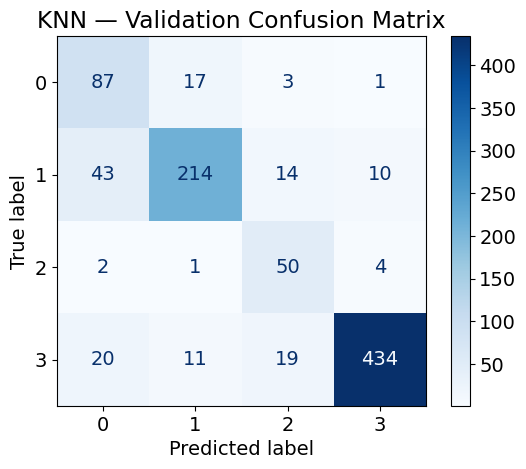

===== KNN: Test Set =====
Accuracy:          0.8484
Precision (macro): 0.7623
Recall (macro):    0.8292
F1-score (macro):  0.7876

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.76      0.64       108
           1       0.85      0.77      0.81       282
           2       0.68      0.88      0.76        57
           3       0.98      0.91      0.94       483

    accuracy                           0.85       930
   macro avg       0.76      0.83      0.79       930
weighted avg       0.87      0.85      0.85       930



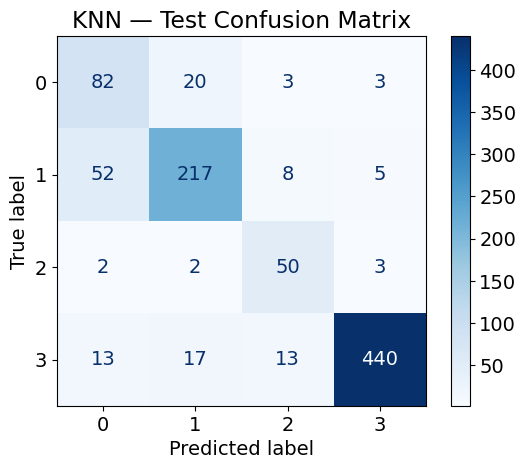

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=5,
        weights="distance",
        metric="minkowski",
        p=2,
        n_jobs=-1
    ))
])

# Train
knn_model.fit(train_X, train_Y)

# Predictions
knn_val_pred = knn_model.predict(val_X)
knn_test_pred = knn_model.predict(test_X)
knn_test_prob = knn_model.predict_proba(test_X)

# Evaluation

knn_val_metrics = evaluate_model(
    val_Y, knn_val_pred, "KNN", "Validation"
)

## Step 5B: SVM and Random Forest — 15 points

Train an SVM classifier and a Random Forest classifier using the same selected features and data split.

### Your task

1. Use a standardized pipeline for SVM.
2. Train both models using the training set.
3. Evaluate both models on the validation set.
4. State the key settings used for each model, such as SVM kernel/C and Random Forest number of trees.
5. Briefly compare the validation macro F1-scores.

===== SVM: Validation Set =====
Accuracy:          0.8796
Precision (macro): 0.8119
Recall (macro):    0.8428
F1-score (macro):  0.8253

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.81      0.74       108
           1       0.88      0.82      0.85       281
           2       0.73      0.81      0.77        57
           3       0.95      0.94      0.94       484

    accuracy                           0.88       930
   macro avg       0.81      0.84      0.83       930
weighted avg       0.88      0.88      0.88       930



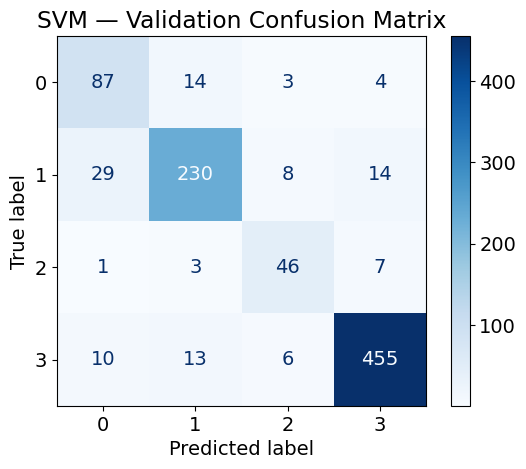

===== SVM: Test Set =====
Accuracy:          0.8720
Precision (macro): 0.7958
Recall (macro):    0.8257
F1-score (macro):  0.8083

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.76      0.68       108
           1       0.87      0.81      0.84       282
           2       0.74      0.79      0.76        57
           3       0.97      0.94      0.95       483

    accuracy                           0.87       930
   macro avg       0.80      0.83      0.81       930
weighted avg       0.88      0.87      0.88       930



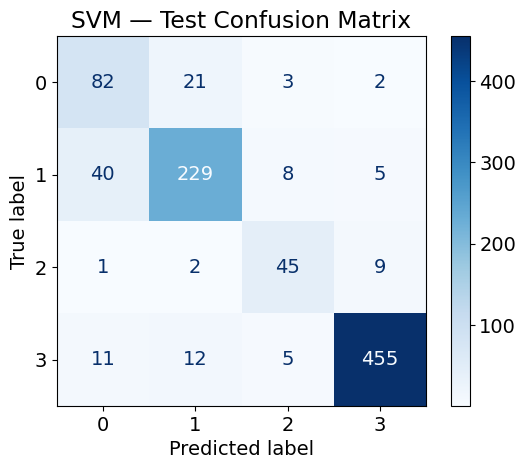

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=42
    ))
])

# Train
svm_model.fit(train_X, train_Y)

# Predictions
svm_val_pred = svm_model.predict(val_X)
svm_test_pred = svm_model.predict(test_X)
svm_test_prob = svm_model.predict_proba(test_X)

# Evaluation
svm_val_metrics = evaluate_model(
    val_Y, svm_val_pred, "SVM", "Validation"
)

===== Random Forest: Validation Set =====
Accuracy:          0.8882
Precision (macro): 0.8132
Recall (macro):    0.8707
F1-score (macro):  0.8374

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.81      0.77       108
           1       0.87      0.86      0.87       281
           2       0.67      0.89      0.77        57
           3       0.97      0.92      0.95       484

    accuracy                           0.89       930
   macro avg       0.81      0.87      0.84       930
weighted avg       0.90      0.89      0.89       930



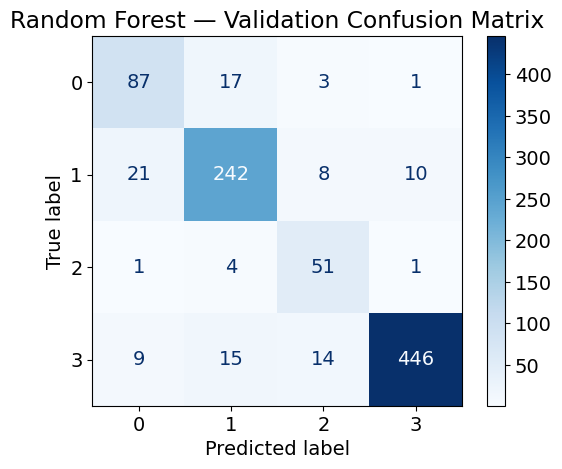

===== Random Forest: Test Set =====
Accuracy:          0.8871
Precision (macro): 0.8161
Recall (macro):    0.8750
F1-score (macro):  0.8414

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.75      0.71       108
           1       0.85      0.86      0.86       282
           2       0.75      0.96      0.85        57
           3       0.99      0.92      0.96       483

    accuracy                           0.89       930
   macro avg       0.82      0.88      0.84       930
weighted avg       0.90      0.89      0.89       930



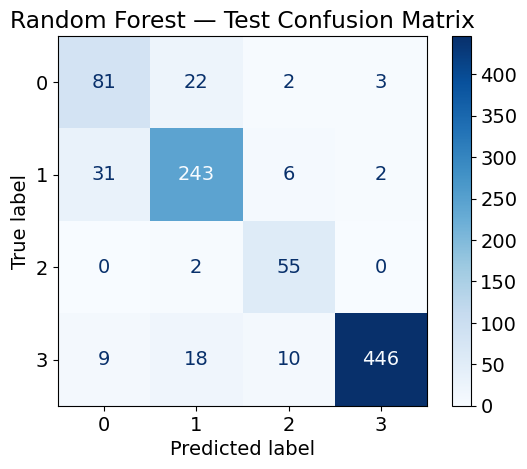

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(train_X, train_Y)

# Predictions
rf_val_pred = rf_model.predict(val_X)
rf_test_pred = rf_model.predict(test_X)
rf_test_prob = rf_model.predict_proba(test_X)

# Evaluation
rf_val_metrics = evaluate_model(
    val_Y, rf_val_pred, "Random Forest", "Validation"
)

## Step 6: Final test evaluation and comparison — 15 points

After reviewing validation performance, evaluate all three final models once on the untouched test set.

### Your task

1. Create a comparison table containing Accuracy, macro Precision, macro Recall, and macro F1-score for KNN, SVM, and Random Forest.
2. Create a comparison plot.
3. Select the best model using macro F1-score as the primary criterion.
4. In 2–3 sentences, justify the choice using the test metrics and confusion matrix.

Do not select a model based only on Accuracy. Macro F1-score gives equal importance to each posture class.

,Model,Accuracy,Precision (macro),Recall (macro),F1-score (macro)
0,Random Forest,0.8871,0.8161,0.8750,0.8414
1,SVM,0.8720,0.7958,0.8257,0.8083
2,KNN,0.8484,0.7623,0.8292,0.7876


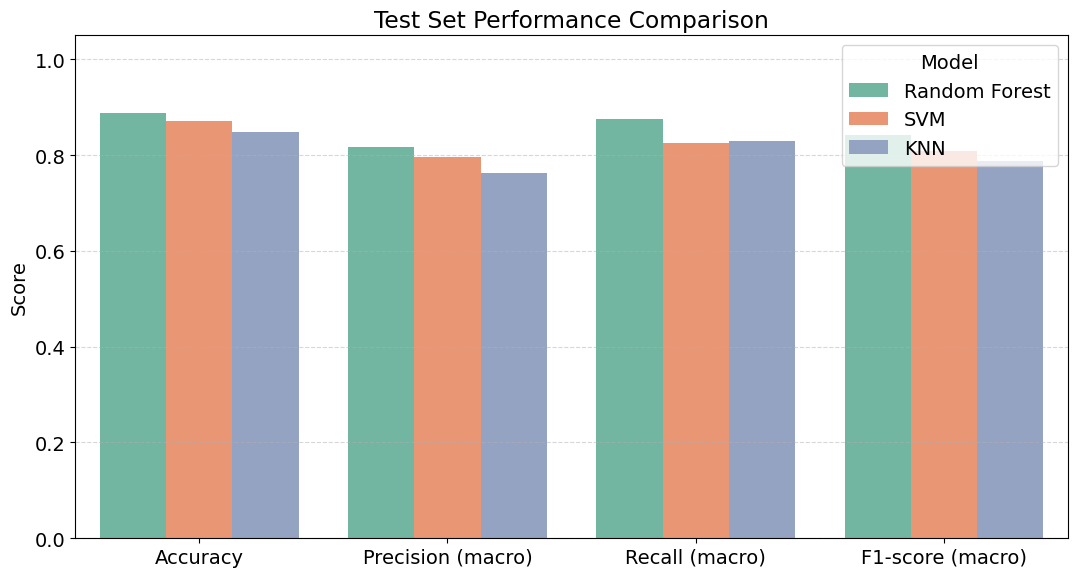

In [ ]:
# Final predictions on the untouched test set
knn_test_pred = knn_model.predict(test_X)
svm_test_pred = svm_model.predict(test_X)
rf_test_pred = rf_model.predict(test_X)

# Final metrics
knn_test_metrics = evaluate_model(
    test_Y, knn_test_pred, "KNN", "Test"
)

svm_test_metrics = evaluate_model(
    test_Y, svm_test_pred, "SVM", "Test"
)

rf_test_metrics = evaluate_model(
    test_Y, rf_test_pred, "Random Forest", "Test"
)

comparison_df = pd.DataFrame([
    knn_test_metrics,
    svm_test_metrics,
    rf_test_metrics
]).drop(columns="Dataset")

comparison_df = comparison_df.sort_values(
    "F1-score (macro)",
    ascending=False
).reset_index(drop=True)

display(comparison_df.round(4))

comparison_long = comparison_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Model",
    palette="Set2"
)

plt.ylim(0, 1.05)
plt.title("Final Test-set Performance Comparison")
plt.xlabel("")
plt.ylabel("Score")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

best_model = comparison_df.loc[0, "Model"]
best_f1 = comparison_df.loc[0, "F1-score (macro)"]

print(f"Best model by test macro F1-score: {best_model}")
print(f"Best macro F1-score: {best_f1:.4f}")